# Binary logistic regression

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad
import sklearn.datasets as skldata

# Set a random seed for reproducibility
np.random.seed(228)
jax.random.PRNGKey(228)

def logistic_loss(w, X, y, mu=1):
    m, n = X.shape
    return jnp.sum(jnp.logaddexp(0, -y * (X @ w))) / m + mu / 2 * jnp.sum(w**2)

def generate_problem(m=1000, n=300, mu=1):
    X, y = skldata.make_classification(n_classes=2, n_features=n, n_samples=m, n_informative=n//2, random_state=0)
    X = jnp.array(X)
    y = jnp.array(y)
    return X, y

def compute_optimal(X, y, mu):
    w = cp.Variable(X.shape[1])
    objective = cp.Minimize(cp.sum(cp.logistic(cp.multiply(-y, X @ w))) / len(y) + mu / 2 * cp.norm(w, 2)**2)
    problem = cp.Problem(objective)
    problem.solve()
    return w.value, problem.value

def stochastic_gradient_descent(X, y, x_0, learning_rate, iterations, batch_size=1, mu=0):
    m, n = X.shape
    x = x_0
    flops = 0
    trajectory = [x]
    flops_trajectory = [flops]
    for _ in range(iterations):
        indices = np.random.choice(m, batch_size, replace=False)
        X_batch, y_batch = X[indices], y[indices]
        f_batch = lambda w: logistic_loss(w, X=X_batch, y=y_batch, mu=mu)
        grad_f_batch = grad(f_batch)
        x -= learning_rate * grad_f_batch(x)
        trajectory.append(x)
        flops += (2 * n * batch_size + n)
        flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def sag(X, y, x_0, learning_rate, iterations, batch_size=1, mu=1):
    m, n = X.shape
    x = x_0.copy()
    gradients = np.zeros((m, n))
    for i in range(m):
        f_i = lambda w: logistic_loss(w, X[i:i+1], y[i:i+1], mu=mu)
        grad_f_i = grad(f_i)
        gradients[i] = grad_f_i(x)
    average_grad = np.mean(gradients, axis=0)
    flops = 0
    trajectory = [x.copy()]
    flops_trajectory = [flops]
    for _ in range(iterations):
        indices = np.random.choice(m, batch_size, replace=False)
        for idx in indices:
            f_i = lambda w: logistic_loss(w, X[idx:idx+1], y[idx:idx+1], mu=mu)
            grad_f_i = grad(f_i)
            new_grad = grad_f_i(x)
            average_grad += (new_grad - gradients[idx]) / m
            gradients[idx] = new_grad
        x -= learning_rate * average_grad
        trajectory.append(x.copy())
        flops += (2 * n * batch_size + n)
        flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def svrg(X, y, x_0, learning_rate, epoch_length, iterations, batch_size=1, mu=1):
    m, n = X.shape
    x = x_0.copy()
    flops = 0
    trajectory = [x.copy()]
    flops_trajectory = [flops]
    num_outer_iters = iterations // epoch_length
    for _ in range(num_outer_iters):
        full_grad = grad(lambda w: logistic_loss(w, X, y, mu))(x)
        x_tilde = x.copy()
        for _ in range(epoch_length):
            indices = np.random.choice(m, batch_size, replace=False)
            X_batch, y_batch = X[indices], y[indices]
            grad_fn = lambda w: logistic_loss(w, X_batch, y_batch, mu)
            grad_current = grad(grad_fn)(x)
            grad_tilde = grad(grad_fn)(x_tilde)
            corrected_grad = grad_current - grad_tilde + full_grad
            x -= learning_rate * corrected_grad
            trajectory.append(x.copy())
            flops += (4 * n * batch_size + 2 * n)
            flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def compute_metrics(trajectory, x_star, f_star, f, flops_trajectory):
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "flops": flops_trajectory,
    }
    return metrics

def run_experiments(params):
    m, n, mu = params["m"], params["n"], params["mu"]
    methods = params["methods"]
    results = {}

    X, y = generate_problem(m, n, mu)
    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n,))
    # Compute the optimal solution using CVXPY
    x_star, f_star = compute_optimal(X, y, mu)

    for method_params in methods:
        method = method_params["method"]
        if method == "SGD":
            trajectory, flops_trajectory = stochastic_gradient_descent(
                X, y, x_0, method_params["learning_rate"], method_params["iterations"], method_params["batch_size"], mu
            )
        elif method == "SAG":
            trajectory, flops_trajectory = sag(
                X, y, x_0, method_params["learning_rate"], method_params["iterations"], method_params["batch_size"], mu
            )
        elif method == "SVRG":
            trajectory, flops_trajectory = svrg(
                X, y, x_0, method_params["learning_rate"], method_params["epoch_length"], method_params["iterations"], method_params["batch_size"], mu
            )
        label = f"{method} batch {method_params['batch_size']}"
        results[label] = compute_metrics(trajectory, x_star, f_star, f=lambda x: logistic_loss(x, X, y, mu), flops_trajectory=flops_trajectory)
    return results

def plot_results(results, params):
    plt.figure(figsize=(10, 3.5))
    mu = params["mu"]
    m = params["m"]
    n = params["n"]

    if mu > 1e-2:
        plt.suptitle(f"Strongly convex binary logistic regression. m={m}, n={n}, mu={mu}.")
    else:
        plt.suptitle(f"Convex binary logistic regression. m={m}, n={n}, mu={mu}.")

    plt.subplot(1, 3, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(1, 3, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'], label=method)
    plt.xlabel('Iteration')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(1, 3, 3)
    for method, metrics in results.items():
        plt.plot(metrics["flops"], metrics['f_gap'])
    plt.xlabel('FLOPS')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.00))
    # Adjust layout to make space for the legend below
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f"sgd_{mu}_{m}_{n}.pdf")
    plt.show()

<>:154: SyntaxWarning: invalid escape sequence '\|'
<>:154: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_3541/4920783.py:154: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')


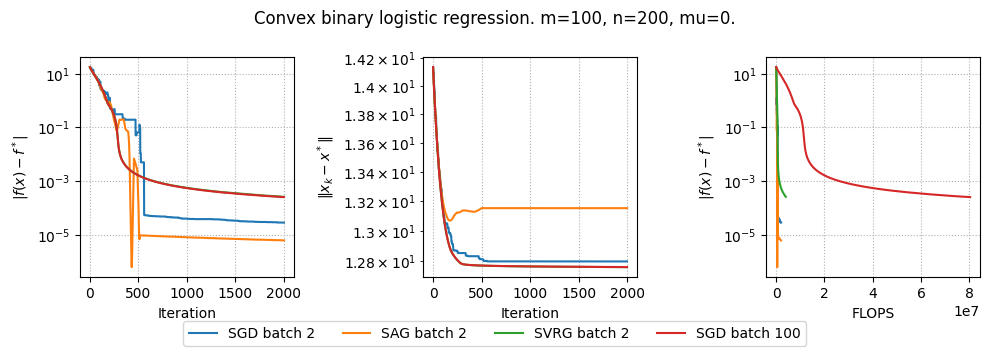

In [5]:
params = {
    "mu": 0,
    "m": 100,
    "n": 200,
    "methods": [
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 2000,
        },
        {
            "method": "SAG",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 2000,
        },
        {
            "method": "SVRG",
            "learning_rate": 1e-2,
            "epoch_length": 3,
            "batch_size": 2,
            "iterations": 2000,
        },
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 100,
            "iterations": 2000,
        },
    ]
}

results = run_experiments(params)
plot_results(results, params)

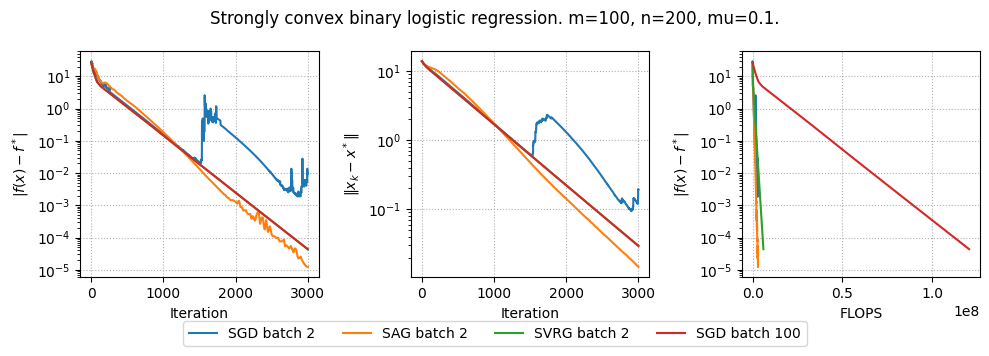

In [6]:
params = {
    "mu": 1e-1,
    "m": 100,
    "n": 200,
    "methods": [
        {
            "method": "SGD",
            "learning_rate": 2e-2,
            "batch_size": 2,
            "iterations": 3000,
        },
        {
            "method": "SAG",
            "learning_rate": 2e-2,
            "batch_size": 2,
            "iterations": 3000,
        },
        {
            "method": "SVRG",
            "learning_rate": 2e-2,
            "epoch_length": 3,
            "batch_size": 2,
            "iterations": 3000,
        },
        {
            "method": "SGD",
            "learning_rate": 2e-2,
            "batch_size": 100,
            "iterations": 3000,
        },
    ]
}

results = run_experiments(params)
plot_results(results, params)

# Linear least squares

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import jax
from jax import numpy as jnp, grad
import sklearn.datasets as skldata

# Set a random seed for reproducibility
np.random.seed(228)
jax.random.PRNGKey(228)

def least_squares_loss(w, X, y, mu=1):
    m, n = X.shape
    residuals = X @ w - y
    return jnp.sum(residuals ** 2) / (2 * m) + mu / 2 * jnp.sum(w ** 2)

def generate_problem(m=1000, n=300, mu=1):
    X, y = skldata.make_regression(n_features=n, n_samples=m, noise=1e-3, random_state=0)
    X = jnp.array(X)
    y = jnp.array(y)
    return X, y

def compute_optimal(X, y, mu):
    w = cp.Variable(X.shape[1])
    residuals = X @ w - y
    objective = cp.Minimize(cp.sum_squares(residuals) / (2 * len(y)) + mu / 2 * cp.norm(w, 2)**2)
    problem = cp.Problem(objective)
    problem.solve()
    return w.value, problem.value

def stochastic_gradient_descent(X, y, x_0, learning_rate, iterations, batch_size=1, mu=1):
    m, n = X.shape
    x = x_0
    flops = 0
    trajectory = [x]
    flops_trajectory = [flops]
    for _ in range(iterations):
        indices = np.random.choice(m, batch_size, replace=False)
        X_batch, y_batch = X[indices], y[indices]
        f_batch = lambda w: least_squares_loss(w, X=X_batch, y=y_batch, mu=mu)
        grad_f_batch = grad(f_batch)
        x -= learning_rate * grad_f_batch(x)
        trajectory.append(x)
        flops += (2 * n * batch_size + n)
        flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def sag(X, y, x_0, learning_rate, iterations, batch_size=1, mu=1):
    m, n = X.shape
    x = x_0.copy()
    gradients = np.zeros((m, n))
    for i in range(m):
        f_i = lambda w: least_squares_loss(w, X[i:i+1], y[i:i+1], mu=mu)
        grad_f_i = grad(f_i)
        gradients[i] = grad_f_i(x)
    average_grad = np.mean(gradients, axis=0)
    flops = 0
    trajectory = [x.copy()]
    flops_trajectory = [flops]
    for _ in range(iterations):
        indices = np.random.choice(m, batch_size, replace=False)
        for idx in indices:
            f_i = lambda w: least_squares_loss(w, X[idx:idx+1], y[idx:idx+1], mu=mu)
            grad_f_i = grad(f_i)
            new_grad = grad_f_i(x)
            average_grad += (new_grad - gradients[idx]) / m
            gradients[idx] = new_grad
        x -= learning_rate * average_grad
        trajectory.append(x.copy())
        flops += (2 * n * batch_size + n)
        flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def svrg(X, y, x_0, learning_rate, epoch_length, iterations, batch_size=1, mu=1):
    m, n = X.shape
    x = x_0.copy()
    flops = 0
    trajectory = [x.copy()]
    flops_trajectory = [flops]
    num_outer_iters = iterations // epoch_length
    for _ in range(num_outer_iters):
        full_grad = grad(lambda w: least_squares_loss(w, X, y, mu))(x)
        x_tilde = x.copy()
        for _ in range(epoch_length):
            indices = np.random.choice(m, batch_size, replace=False)
            X_batch, y_batch = X[indices], y[indices]
            grad_fn = lambda w: least_squares_loss(w, X_batch, y_batch, mu)
            grad_current = grad(grad_fn)(x)
            grad_tilde = grad(grad_fn)(x_tilde)
            corrected_grad = grad_current - grad_tilde + full_grad
            x -= learning_rate * corrected_grad
            trajectory.append(x.copy())
            flops += (4 * n * batch_size + 2 * n)
            flops_trajectory.append(flops)
    return trajectory, flops_trajectory

def compute_metrics(trajectory, x_star, f_star, f, flops_trajectory):
    metrics = {
        "f_gap": [jnp.abs(f(x) - f_star) for x in trajectory],
        "x_gap": [jnp.linalg.norm(x - x_star) for x in trajectory],
        "flops": flops_trajectory,
    }
    return metrics

def run_experiments(params):
    m, n, mu = params["m"], params["n"], params["mu"]
    methods = params["methods"]
    results = {}

    X, y = generate_problem(m, n, mu)
    x_0 = jax.random.normal(jax.random.PRNGKey(0), (n,))
    # Compute the optimal solution using CVXPY
    x_star, f_star = compute_optimal(X, y, mu)

    for method_params in methods:
        method = method_params["method"]
        if method == "SGD":
            trajectory, flops_trajectory = stochastic_gradient_descent(
                X, y, x_0, method_params["learning_rate"], method_params["iterations"], method_params["batch_size"], mu
            )
        elif method == "SAG":
            trajectory, flops_trajectory = sag(
                X, y, x_0, method_params["learning_rate"], method_params["iterations"], method_params["batch_size"], mu
            )
        elif method == "SVRG":
            trajectory, flops_trajectory = svrg(
                X, y, x_0, method_params["learning_rate"], method_params["epoch_length"], method_params["iterations"], method_params["batch_size"], mu
            )
        label = f"{method} batch {method_params['batch_size']}"
        results[label] = compute_metrics(trajectory, x_star, f_star, f=lambda x: least_squares_loss(x, X, y, mu), flops_trajectory=flops_trajectory)
    return results

def plot_results(results, params):
    plt.figure(figsize=(10, 3.5))
    mu = params["mu"]
    m = params["m"]
    n = params["n"]

    if mu > 1e-2:
        plt.suptitle(f"Strongly convex quadratics. m={m}, n={n}, mu={mu}.")
    else:
        plt.suptitle(f"Convex quadratics. m={m}, n={n}, mu={mu}.")

    plt.subplot(1, 3, 1)
    for method, metrics in results.items():
        plt.plot(metrics['f_gap'])
    plt.xlabel('Iteration')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(1, 3, 2)
    for method, metrics in results.items():
        plt.plot(metrics['x_gap'], label=method)
    plt.xlabel('Iteration')
    plt.ylabel('$\|x_k - x^*\|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    plt.subplot(1, 3, 3)
    for method, metrics in results.items():
        plt.plot(metrics["flops"], metrics['f_gap'])
    plt.xlabel('FLOPS')
    plt.ylabel(r'$|f(x) -f^*|$')
    plt.yscale('log')
    plt.grid(linestyle=":")

    # Place the legend below the plots
    plt.figlegend(loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.00))
    # Adjust layout to make space for the legend below
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(f"sgd_{mu}_{m}_{n}.pdf")
    plt.show()

<>:156: SyntaxWarning: invalid escape sequence '\|'
<>:156: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_3541/1438879072.py:156: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|x_k - x^*\|$')


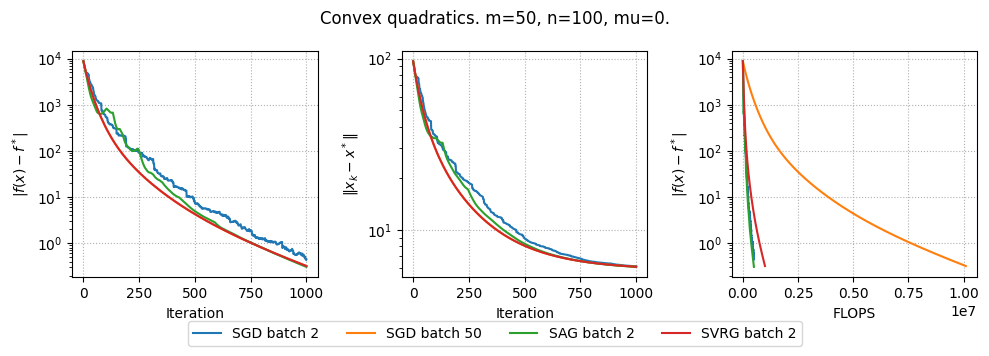

In [8]:
params = {
    "mu": 0,
    "m": 50,
    "n": 100,
    "methods": [
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 1000,
        },
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 50,
            "iterations": 1000,
        },
        {
            "method": "SAG",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 1000,
        },
        {
            "method": "SVRG",
            "learning_rate": 1e-2,
            "epoch_length": 2,
            "batch_size": 2,
            "iterations": 1000,
        },
    ]
}

results = run_experiments(params)
plot_results(results, params)

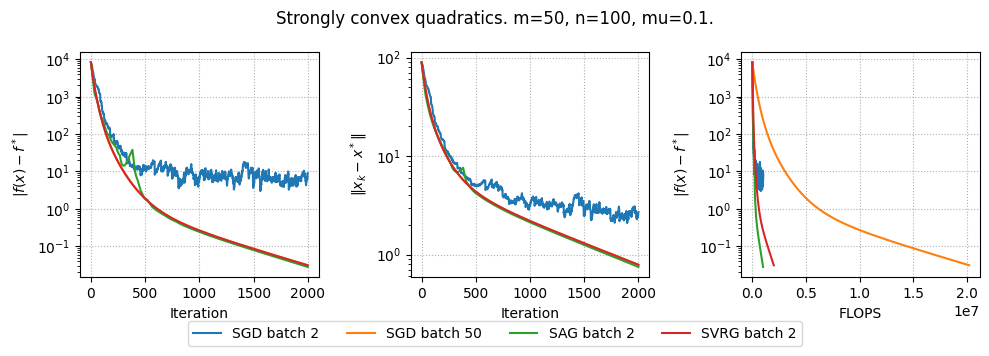

In [9]:
params = {
    "mu": 1e-1,
    "m": 50,
    "n": 100,
    "methods": [
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 2000,
        },
        {
            "method": "SGD",
            "learning_rate": 1e-2,
            "batch_size": 50,
            "iterations": 2000,
        },
        {
            "method": "SAG",
            "learning_rate": 1e-2,
            "batch_size": 2,
            "iterations": 2000,
        },
        {
            "method": "SVRG",
            "learning_rate": 1e-2,
            "epoch_length": 2,
            "batch_size": 2,
            "iterations": 2000,
        },
    ]
}

results = run_experiments(params)
plot_results(results, params)

SVRG и SAG значительно быстрее и стабильнее обычного SGD как на линейной регрессии так и на логистической, особенно в сильно выпуклом случае. SVRG показывает самую высокую точность и монотонную сходимость, но требует периодического вычисления полного градиента. Обычный SGD с маленьким батчем сильно шумит и медленно сходится, а с большим батчем дорогой по вычислениям.

# Polyak Stepsize

## Скорость сходимости $O(1/\sqrt{k})$

Пусть $w^*$ — минимум. Раскроем квадрат расстояния:

$$\|w^{k+1} - w^*\|^2 = \|w^k - \eta_k \nabla L(w^k) - w^*\|^2 =$$
$$= \|w^k - w^*\|^2 - 2\eta_k \langle \nabla L(w^k), w^k - w^* \rangle + \eta_k^2 \|\nabla L(w^k)\|^2.$$

Из выпуклости: $\langle \nabla L(w^k), w^k - w^* \rangle \geq L(w^k) - L(w^*)$.

$$\|w^{k+1} - w^*\|^2 \leq \|w^k - w^*\|^2 - 2\eta_k \Delta_k + \eta_k^2 g_k,$$

где $\Delta_k = L(w^k) - L(w^*)$, $g_k = \|\nabla L(w^k)\|^2$. Шаг Поляка $\eta_k = \Delta_k / g_k$ минимизирует правую часть.

$$\|w^{k+1} - w^*\|^2 \leq \|w^k - w^*\|^2 - \frac{\Delta_k^2}{g_k}.$$

Из $g_k \leq G^2$ получаем $\Delta_k^2 \leq G^2(\|w^k - w^*\|^2 - \|w^{k+1} - w^*\|^2)$.

$$\sum_{i=0}^k \Delta_i^2 \leq G^2 \|w^0 - w^*\|^2.$$

Так как $\min_{i \leq k} \Delta_i \leq \sqrt{\frac{1}{k+1}\sum_{i=0}^k \Delta_i^2}$,

$$\min_{i \in [k]} (L(w^i) - L(w^*)) \leq \frac{G \|w^0 - w^*\|}{\sqrt{k+1}} = O(1/\sqrt{k}).$$


## Практический смысл и ограничения

В перепараметризованных моделях (глубокое обучение, где тренировочный лосс можно сделать почти нулевым) $L(w^*) \approx 0$ известно. Также в МНК без шума или когда оптимальное значение задано структурой задачи.

Для квадратичных функций $L(w) = \frac{1}{2}w^2$ градиент неограничен при $\|w\| \to \infty$. Также для логистической регрессии без регуляризации.

## Улучшенная скорость $O(1/k)$ при $\ell$-гладкости

Для $\ell$-гладких выпуклых функций выполняется:

$$\|\nabla L(w)\|^2 \leq 2\ell (L(w) - L(w^*)).$$

То есть $g_k \leq 2\ell \Delta_k$.

$$\|w^{k+1} - w^*\|^2 \leq \|w^k - w^*\|^2 - \frac{\Delta_k^2}{g_k} \leq \|w^k - w^*\|^2 - \frac{\Delta_k}{2\ell}.$$

Отсюда $\Delta_k \leq 2\ell(\|w^k - w^*\|^2 - \|w^{k+1} - w^*\|^2)$.

$$\sum_{i=0}^k \Delta_i \leq 2\ell \|w^0 - w^*\|^2.$$

Поскольку $\min_{i \leq k} \Delta_i \leq \frac{1}{k+1}\sum_{i=0}^k \Delta_i$:

$$\min_{i \in [k]} (L(w^i) - L(w^*)) \leq \frac{2\ell \|w^0 - w^*\|^2}{k+1} = O(1/k).$$


## Пример: квадратичная функция

Для $L(w) = \frac{\ell}{2} w^2$:
- $w^* = 0$, $L(w^*) = 0$
- $\nabla L(w) = \ell w$
- $\Delta_k = \frac{\ell}{2} (w^k)^2$
- $g_k = \ell^2 (w^k)^2$

Шаг Поляка:
$$\eta_k^{\text{Polyak}} = \frac{\Delta_k}{g_k} = \frac{\frac{\ell}{2} (w^k)^2}{\ell^2 (w^k)^2} = \frac{1}{2\ell}.$$

Оптимальный шаг GD: $\eta^{\text{opt}} = \frac{1}{\ell}$.

Шаг Поляка ровно в два раза меньше оптимального постоянного шага.

# Adam и отсутствие сходимости на квадратичной функции

## Закрытая форма для $v^k$

Рекуррентное соотношение для EMA: $v^{k+1} = \beta_2 v^k + (1-\beta_2) \ell^2 (w^{k+1})^2$.

$$v^1 = \beta_2 v^0 + (1-\beta_2) \ell^2 (w^1)^2$$

$$v^2 = \beta_2^2 v^0 + \beta_2(1-\beta_2) \ell^2 (w^1)^2 + (1-\beta_2) \ell^2 (w^2)^2$$

Получаем для $k \geq 1$:

$$v^k = \beta_2^k v^0 + (1-\beta_2) \sum_{i=1}^k \beta_2^{k-i} \ell^2 (w^i)^2$$

## Условие стационарной точки

Определим $a^k = 1 - \frac{\eta \ell}{\sqrt{v^k}}$, тогда обновление: $w^{k+1} = a^k w^k$.

Стационарная точка $w^{k+1} = w^k$, то есть $a^k w^k = w^k$, или $(a^k - 1)w^k = 0$.

ТОгда либо $w^k = 0$ либо $a^k = 1$.

$a^k = 1$ означает $1 - \frac{\eta \ell}{\sqrt{v^k}} = 1$, откуда $\frac{\eta \ell}{\sqrt{v^k}} = 0$, что требует $\sqrt{v^k} \to \infty$. То есть $v^k$ должно неограниченно расти.

Таким образом, единственная конечная стационарная точка — $w^k = 0$.


## Осциллирующая стационарная точка

Рассмотрим условие $w^{k+1} = -w^k$. Тогда $(w^{k+1})^2 = (w^k)^2$

Из $w^{k+1} = a^k w^k$ получаем $a^k = -1$:

$$-1 = 1 - \frac{\eta \ell}{\sqrt{v^k}}$$

$$\frac{\eta \ell}{\sqrt{v^k}} = 2$$

$$\sqrt{v^k} = \frac{\eta \ell}{2}$$

Теперь подставим в рекурсию для $v$. При $(w^{k+1})^2 = (w^k)^2 = \text{const}$:

$$v^{k+1} = \beta_2 v^k + (1-\beta_2) \ell^2 (w^k)^2$$

$v^{k+1} = v^k$ даёт:

$$v^k = \beta_2 v^k + (1-\beta_2) \ell^2 (w^k)^2$$

$$(1-\beta_2) v^k = (1-\beta_2) \ell^2 (w^k)^2$$

$$v^k = \ell^2 (w^k)^2$$

$\sqrt{v^k} = \frac{\eta \ell}{2}$:

$$\frac{\eta \ell}{2} = \sqrt{v^k} = \ell |w^k|$$

$$|w^k| = \frac{\eta}{2}$$

$$(w^k)^2 = \frac{\eta^2}{4}$$

При инициализации с $(w^0)^2 = \eta^2/4$ и соответствующем $v^0 = \ell^2 \eta^2/4$ Adam будет осциллировать между $w$ и $-w$, никогда не сходясь к нулю.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: B=32, eta=0.0320, eta/B=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Best test accuracy: 0.8917
Training: B=32, eta=0.1600, eta/B=0.005
  Best test accuracy: 0.8974
Training: B=32, eta=0.3200, eta/B=0.01
  Best test accuracy: 0.8917
Training: B=32, eta=0.6400, eta/B=0.02
  Best test accuracy: 0.6385
Training: B=64, eta=0.0640, eta/B=0.001
  Best test accuracy: 0.8942
Training: B=64, eta=0.3200, eta/B=0.005
  Best test accuracy: 0.8920
Training: B=64, eta=0.6400, eta/B=0.01
  Best test accuracy: 0.8743
Training: B=64, eta=1.2800, eta/B=0.02
  Best test accuracy: 0.1000
Training: B=128, eta=0.1280, eta/B=0.001
  Best test accuracy: 0.8932
Training: B=128, eta=0.6400, eta/B=0.005
  Best test accuracy: 0.8830
Training: B=128, eta=1.2800, eta/B=0.01
  Best test accuracy: 0.1000
Training: B=128, eta=2.5600, eta/B=0.02
  Best test accuracy: 0.1000
Training: B=256, eta=0.2560, eta/B=0.001
  Best test accuracy: 0.8903
Training: B=256, eta=1.2800, eta/B=0.005
  Best test accuracy: 0.1000
Training: B=256, eta=2.5600, eta/B=0.01
  Best test accuracy: 0.1000
Train

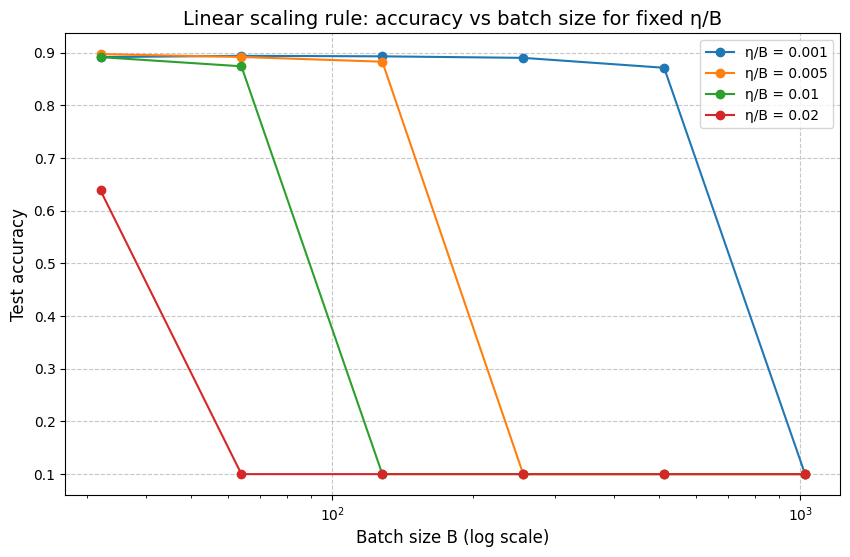

B=  32, η=0.0320, η/B=0.0010, acc=0.8917
B=  32, η=0.1600, η/B=0.0050, acc=0.8974
B=  32, η=0.3200, η/B=0.0100, acc=0.8917
B=  32, η=0.6400, η/B=0.0200, acc=0.6385
B=  64, η=0.0640, η/B=0.0010, acc=0.8942
B=  64, η=0.3200, η/B=0.0050, acc=0.8920
B=  64, η=0.6400, η/B=0.0100, acc=0.8743
B=  64, η=1.2800, η/B=0.0200, acc=0.1000
B= 128, η=0.1280, η/B=0.0010, acc=0.8932
B= 128, η=0.6400, η/B=0.0050, acc=0.8830
B= 128, η=1.2800, η/B=0.0100, acc=0.1000
B= 128, η=2.5600, η/B=0.0200, acc=0.1000
B= 256, η=0.2560, η/B=0.0010, acc=0.8903
B= 256, η=1.2800, η/B=0.0050, acc=0.1000
B= 256, η=2.5600, η/B=0.0100, acc=0.1000
B= 256, η=5.1200, η/B=0.0200, acc=0.1000
B= 512, η=0.5120, η/B=0.0010, acc=0.8715
B= 512, η=2.5600, η/B=0.0050, acc=0.1000
B= 512, η=5.1200, η/B=0.0100, acc=0.1000
B= 512, η=10.2400, η/B=0.0200, acc=0.1000
B=1024, η=1.0240, η/B=0.0010, acc=0.1000
B=1024, η=5.1200, η/B=0.0050, acc=0.1000
B=1024, η=10.2400, η/B=0.0100, acc=0.1000
B=1024, η=20.4800, η/B=0.0200, acc=0.1000


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def create_model():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

batch_sizes = [32, 64, 128, 256, 512, 1024]
eta_over_B_values = [0.001, 0.005, 0.01, 0.02]

results = []

for B in batch_sizes:
    for ratio in eta_over_B_values:
        eta = ratio * B
        print(f"Training: B={B}, eta={eta:.4f}, eta/B={ratio}")

        model = create_model()
        model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=eta),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            x_train, y_train,
            batch_size=B,
            epochs=30,
            validation_data=(x_test, y_test),
            verbose=0
        )

        test_acc = max(history.history['val_accuracy'])
        results.append({
            'batch_size': B,
            'learning_rate': eta,
            'eta_over_B': ratio,
            'test_accuracy': test_acc
        })
        print(f"  Best test accuracy: {test_acc:.4f}")

plt.figure(figsize=(10, 6))
for ratio in eta_over_B_values:
    accuracies = []
    for B in batch_sizes:
        matches = [r for r in results if r['batch_size'] == B and r['eta_over_B'] == ratio]
        if matches:
            accuracies.append(matches[0]['test_accuracy'])
        else:
            accuracies.append(None)
    plt.plot(batch_sizes, accuracies, marker='o', label=f'η/B = {ratio}')

plt.xscale('log')
plt.xlabel('Batch size B (log scale)', fontsize=12)
plt.ylabel('Test accuracy', fontsize=12)
plt.title('Linear scaling rule: accuracy vs batch size for fixed η/B', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

for r in results:
    print(f"B={r['batch_size']:4d}, η={r['learning_rate']:.4f}, η/B={r['eta_over_B']:.4f}, acc={r['test_accuracy']:.4f}")

Линейное правило масштабирования работает только для небольших learning rates (η/B = 0.001). При этом соотношении точность держится на уровне 0.89-0.89 для B=32-256, падая до 0.87 при B=512 и полностью расходясь при B=1024. Для всех остальных соотношений (η/B ≥ 0.005) метод расходится уже при B ≥ 64, потому что η становится слишком большим.

Критический batch size для этой задачи около 256. Дальнейшее увеличение B требует уменьшения η/B, иначе градиентный шум становится слишком маленьким, а шаг слишком большим, что приводит к расходимости.

Training with batch size 1, lr=0.0001
Training with batch size 5, lr=0.0005
Training with batch size 10, lr=0.001
Training with batch size 50, lr=0.005
Training with batch size 200, lr=0.01


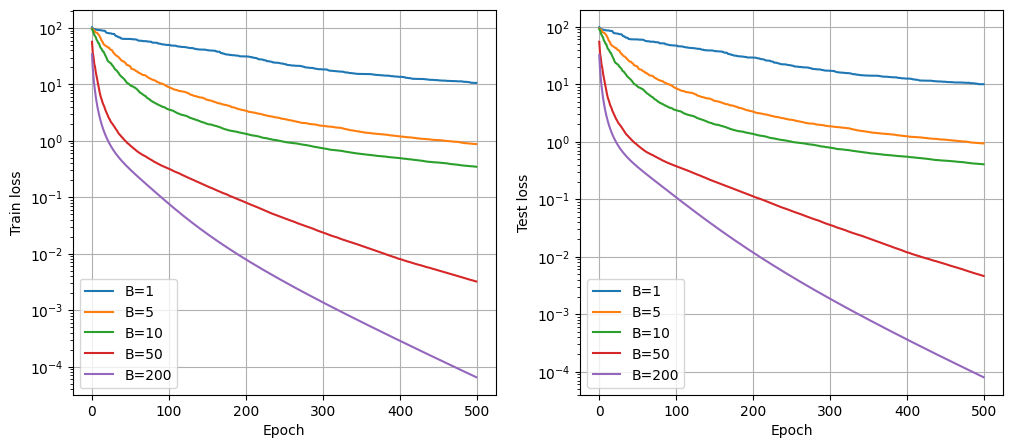


Final losses after 500 epochs:
B=  1: train=10.646637, test=10.024066
B=  5: train=0.876807, test=0.935076
B= 10: train=0.347535, test=0.404703
B= 50: train=0.003219, test=0.004632
B=200: train=0.000065, test=0.000080

=== r=1, n=5 ===
GD test=0.000006, SGD test=4.157489, gap=4.157483

=== r=1, n=10 ===
GD test=0.000003, SGD test=6.073838, gap=6.073835

=== r=1, n=15 ===
GD test=0.006908, SGD test=9.909529, gap=9.902621

=== r=2, n=5 ===
GD test=0.000643, SGD test=1.282642, gap=1.281999

=== r=2, n=10 ===
GD test=0.000019, SGD test=6.197292, gap=6.197273

=== r=2, n=15 ===
GD test=0.001156, SGD test=12.662835, gap=12.661679

=== r=4, n=5 ===
GD test=0.006477, SGD test=8.321506, gap=8.315029

=== r=4, n=10 ===
GD test=0.008563, SGD test=16.298193, gap=16.289630

=== r=4, n=15 ===
GD test=0.115199, SGD test=27.758583, gap=27.643384


In [3]:
import numpy as np
import matplotlib.pyplot as plt

n = 10
r = 2
m = 200
m_test = 100

np.random.seed(42)

V = np.random.randn(n, r)
X_star = V @ V.T
X_star = X_star / np.linalg.norm(X_star, ord=2)

A_train = []
for _ in range(m):
    G = np.random.randn(n, n)
    A = (G + G.T) / 2
    A_train.append(A)
A_train = np.array(A_train)
y_train = np.array([np.trace(A @ X_star) for A in A_train])

A_test = []
for _ in range(m_test):
    G = np.random.randn(n, n)
    A = (G + G.T) / 2
    A_test.append(A)
A_test = np.array(A_test)
y_test = np.array([np.trace(A @ X_star) for A in A_test])

def loss(U, A, y):
    X = U @ U.T
    pred = np.array([np.trace(Ai @ X) for Ai in A])
    return np.mean((y - pred)**2) / 2

def grad(U, A, y):
    X = U @ U.T
    m_batch = len(A)
    grad_U = np.zeros_like(U)
    for i in range(m_batch):
        pred = np.trace(A[i] @ X)
        residual = pred - y[i]
        grad_U += residual * (A[i] @ U)
    return (2 * grad_U) / m_batch

batch_sizes = [1, 5, 10, 50, m]
learning_rates = {1: 0.0001, 5: 0.0005, 10: 0.001, 50: 0.005, m: 0.01}
epochs = 500

train_losses = {}
test_losses = {}

U0 = np.random.randn(n, r)

for B in batch_sizes:
    lr = learning_rates[B]
    print(f"Training with batch size {B}, lr={lr}")
    losses_train = []
    losses_test = []
    U = U0.copy()

    for epoch in range(epochs):
        if B == m:
            grad_full = grad(U, A_train, y_train)
            U -= lr * grad_full
        else:
            idx = np.random.choice(m, B, replace=False)
            grad_batch = grad(U, A_train[idx], y_train[idx])
            U -= lr * grad_batch

        if np.isnan(U).any():
            print(f"  NaN at epoch {epoch}")
            break

        losses_train.append(loss(U, A_train, y_train))
        losses_test.append(loss(U, A_test, y_test))

    train_losses[B] = losses_train
    test_losses[B] = losses_test

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for B in batch_sizes:
    if len(train_losses[B]) > 0:
        plt.plot(train_losses[B], label=f'B={B}')
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for B in batch_sizes:
    if len(test_losses[B]) > 0:
        plt.plot(test_losses[B], label=f'B={B}')
plt.xlabel('Epoch')
plt.ylabel('Test loss')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

print("\nFinal losses after 500 epochs:")
for B in batch_sizes:
    if len(train_losses[B]) == epochs:
        print(f"B={B:3d}: train={train_losses[B][-1]:.6f}, test={test_losses[B][-1]:.6f}")
    else:
        print(f"B={B:3d}: bad")

ranks = [1, 2, 4]
dimensions = [5, 10, 15]
results_gap = {}

for r_val in ranks:
    for n_val in dimensions:
        if r_val > n_val:
            continue

        print(f"\n=== r={r_val}, n={n_val} ===")

        V = np.random.randn(n_val, r_val)
        X_star = V @ V.T
        X_star = X_star / np.linalg.norm(X_star, ord=2)

        A_train = []
        for _ in range(m):
            G = np.random.randn(n_val, n_val)
            A = (G + G.T) / 2
            A_train.append(A)
        A_train = np.array(A_train)
        y_train = np.array([np.trace(A @ X_star) for A in A_train])

        A_test = []
        for _ in range(m_test):
            G = np.random.randn(n_val, n_val)
            A = (G + G.T) / 2
            A_test.append(A)
        A_test = np.array(A_test)
        y_test = np.array([np.trace(A @ X_star) for A in A_test])

        U0 = np.random.randn(n_val, r_val)

        U_gd = U0.copy()
        for _ in range(500):
            grad_full = grad(U_gd, A_train, y_train)
            U_gd -= 0.01 * grad_full
        test_loss_gd = loss(U_gd, A_test, y_test)

        U_sgd = U0.copy()
        for _ in range(500):
            idx = np.random.choice(m, 1, replace=False)
            grad_batch = grad(U_sgd, A_train[idx], y_train[idx])
            U_sgd -= 0.0001 * grad_batch
        test_loss_sgd = loss(U_sgd, A_test, y_test)

        gap = test_loss_sgd - test_loss_gd
        results_gap[(r_val, n_val)] = gap
        print(f"GD test={test_loss_gd:.6f}, SGD test={test_loss_sgd:.6f}, gap={gap:.6f}")

В задаче matrix sensing без шума GD с полным батчем значительно превосходит SGD по качеству обобщения, чем меньше батч, тем выше финальная ошибка. Разрыв между GD и SGD растёт с увеличением размерности n и ранга r, так как стохастический шум мешает точно восстановить матрицу.